# Bayesian Networks II
# Continuous and Hybrid Networks

This article is part of a series:

- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20I%20-%20Bayesian%20Inference.ipynb">Bayesian Inference I - Bayesian Inference</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20II%20-%20Bayesian%20Linear%20Regression.ipynb">Bayesian Inference II - Bayesian Linear Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20III%20-%20Extending%20Bayesian%20Regression.ipynb">Bayesian Inference III - Extending Bayesian Regression</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20IV%20-%20Bayesian%20Networks%20Discrete.ipynb">Bayesian Inference IV - Discrete Bayesian Networks</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20V%20-%20Bayesian%20Networks%20Continuous%20and%20Hybrid.ipynb">Bayesian Inference V - Continuous and Hybrid Bayesian Networks</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VI%20-%20BN%20Practical%20Applications.ipynb">Bayesian Inference VI - BN Practical Applications</a>
- <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VII%20-%Bayesian%20Modeling%20in%20RStan.ipynb">Bayesian Inference VII - Bayesian Modeling in RStan</a>

## Outline

<ul>
<li>Recap</li>

</br>
<li><code>bnlearn</code> Examples</li>

</ul>


</br>
<p><u>Continuous Networks (GBNs)</u></p>


<ul>
<li>Network Learning</li>

<ul>
    <li>Fitting to Data</li>
    <li>Whitelisting and Blacklisting</li>
    <li>Setting Parameters</li>
</ul>

</br>
<li>Inspecting and Querying</li>

</br>
<li>Exact Inference</li>

</ul>

</br>
<p><u>Hybrid Networks (CGBNs)</u></p>

<ul>
<li>Network Learning</li>

<ul>
    <li>Fitting to Data</i>
    <li>Whitelisting and Blacklisting</li>
    <li>Setting Parameters</li>
</ul>

</br>
<li>Inspecting and Querying</li>

</br>
<li>Approximate Inference</li>

</ul>

## Recap

In the previous article, Bayesian networks (BNs) were introduced as graphical models that represent probabilistic dependencies among variables as nodes in a directed acyclic graph (DAG). The sparsity in connections among variables makes complex Bayesian analysis tractable, and in addition to allowing the injection of prior or expert knowledge, provides a high degree of interpretability. The ability to read insights from the parameters themselves is largely the motivation behind Bayesian networks.

-----
<i>"Bayesian networks... are well suited to complex problems involving large numbers of interrelated uncertain variables. Unlike 'black-box' technologies such as neural networks, the variables and parameters in a Bayesian network are cognitively meaningful and directly interpretable. Unlike traditional rule-based systems, Bayesian networks employ a logically coherent calculus for managing uncertainty and updating conclusions to reflect a new evidence. Tractable algorithms exist for calculating and updating the evidential support for hypotheses of interest. Bayesian networks can combine inputs from diverse sources, including expert knowledge, historical data, new observations, and results from models and simulations."</i>
- Bayesian Networks: A Practical Guide to Applications (2008)
-----

In [ ]:
# install.packages("BiocManager")
# library("BiocManager")

# BiocManager::install("bnlearn")
# BiocManager::install("Rgraphviz")

# BiocManager::install("corpcor")
# BiocManager::install("rbmn")
# BiocManager::install("GGally")

library("bnlearn")
library("Rgraphviz")
library("corpcor")
library("rbmn")
library("GGally")

## <code>bnlearn</code> BN Repository

If you are looking to increase your familiarity with Bayesian networks, but not sure what data sets to explore, consider checking out the <code>bnlearn</code> <a href="https://www.bnlearn.com/bnrepository/">repository</a>. These include small, medium, and large networks of discrete or continuous nature, and in many cases, access to the data and modelstring is provided, as well as .rda or .rds files containing the saved <code>bn</code> object.

With the insurance dataset, for example, I can load the data with <code>data(insurance)</code>, and take the modelstring from the bottom of <a href="https://www.bnlearn.com/documentation/man/insurance.html">this page</a>, found under 'insurance' in the API reference, in order to reproduce the DAG in the repository.

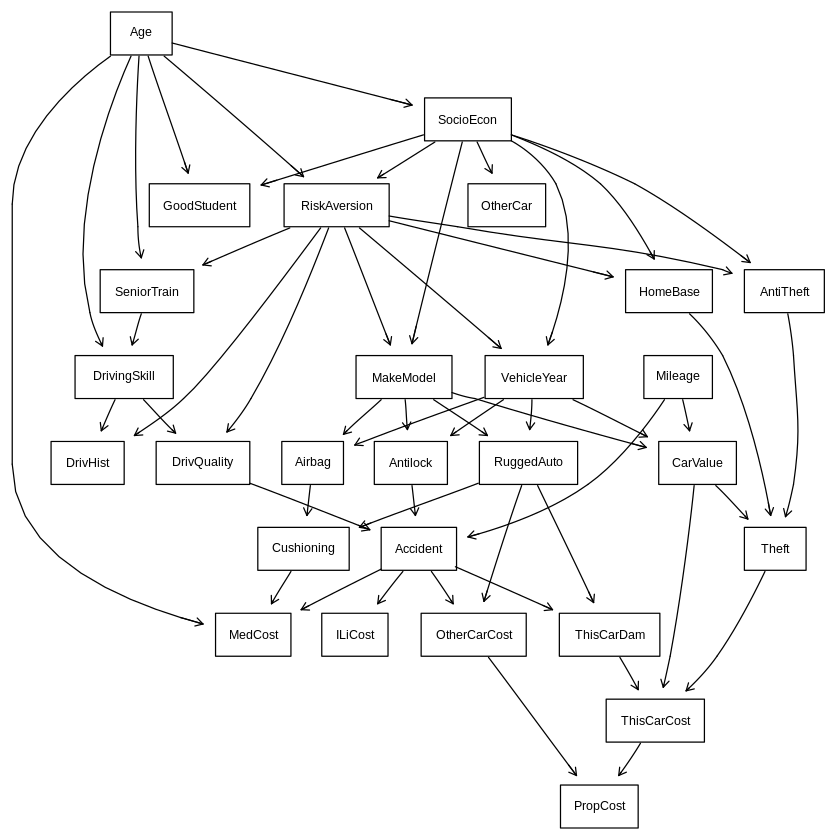

In [ ]:
data(insurance)
modelstring = paste0("[Age][Mileage][SocioEcon|Age][GoodStudent|Age:SocioEcon]",
  "[RiskAversion|Age:SocioEcon][OtherCar|SocioEcon][VehicleYear|SocioEcon:RiskAversion]",
  "[MakeModel|SocioEcon:RiskAversion][SeniorTrain|Age:RiskAversion]",
  "[HomeBase|SocioEcon:RiskAversion][AntiTheft|SocioEcon:RiskAversion]",
  "[RuggedAuto|VehicleYear:MakeModel][Antilock|VehicleYear:MakeModel]",
  "[DrivingSkill|Age:SeniorTrain][CarValue|VehicleYear:MakeModel:Mileage]",
  "[Airbag|VehicleYear:MakeModel][DrivQuality|RiskAversion:DrivingSkill]",
  "[Theft|CarValue:HomeBase:AntiTheft][Cushioning|RuggedAuto:Airbag]",
  "[DrivHist|RiskAversion:DrivingSkill][Accident|DrivQuality:Mileage:Antilock]",
  "[ThisCarDam|RuggedAuto:Accident][OtherCarCost|RuggedAuto:Accident]",
  "[MedCost|Age:Accident:Cushioning][ILiCost|Accident]",
  "[ThisCarCost|ThisCarDam:Theft:CarValue][PropCost|ThisCarCost:OtherCarCost]")

dag = model2network(modelstring)
graphviz.plot(dag)

And of course we could fit it as follows:

In [ ]:
fitted = bn.fit(dag, insurance)

And then query to your heart's delight. You might consider applying one of the network learning algorithms we will cover momentarily, and seeing how closely the network is reproduced without expert knowledge (and how the results of the various types of algorithms differ).

If you ever want to export the modelstring from a DAG, you can use the following syntax.

In [ ]:
export <- modelstring(dag)
export

[1] "[Age][Mileage][SocioEcon|Age][GoodStudent|Age:SocioEcon][OtherCar|SocioEcon][RiskAversion|Age:SocioEcon][AntiTheft|RiskAversion:SocioEcon][HomeBase|RiskAversion:SocioEcon][MakeModel|RiskAversion:SocioEcon][SeniorTrain|Age:RiskAversion][VehicleYear|RiskAversion:SocioEcon][Airbag|MakeModel:VehicleYear][Antilock|MakeModel:VehicleYear][CarValue|MakeModel:Mileage:VehicleYear][DrivingSkill|Age:SeniorTrain][RuggedAuto|MakeModel:VehicleYear][Cushioning|Airbag:RuggedAuto][DrivHist|DrivingSkill:RiskAversion][DrivQuality|DrivingSkill:RiskAversion][Theft|AntiTheft:CarValue:HomeBase][Accident|Antilock:DrivQuality:Mileage][ILiCost|Accident][MedCost|Accident:Age:Cushioning][OtherCarCost|Accident:RuggedAuto][ThisCarDam|Accident:RuggedAuto][ThisCarCost|CarValue:Theft:ThisCarDam][PropCost|OtherCarCost:ThisCarCost]"

Alright, enough of an aside; let's get to continuous networks.

## <u>Continuous Networks (GBNs)</u>

Although there are many possible choices for both the global and local distribution functions, literature has largely focused on two cases:

- Multinomial data, where both the global and local distributions are discrete, and are represented by contingency tables.

- Multivariate Normal data, where the global distribution is MVN, and the local distributions are normal random variables linked by linear constraints. These are called Gaussian BNs (GBNs).

Gaussian Bayesian networks (GBNs) are characterized by the following assumptions:
- Every node follows a normal distribution.
- Nodes without any parent are described by the respective marginal distributions.
- The local distribution of each node can be equivalently expressed as a Gaussian linear model which includes an intercept and the node's parents as explanatory variables, without any interaction term.

Ideally the dataset for demonstration would involve only variables which live anywhere on the real line, or if positive-only, have a mean and standard deviation which makes values below 0 extremely unlikely. This is one reason why discrete or hybrid (or generalized) BNs are often more appealing. With a log-transform, I'll consider the variables in the following dataset close enough to Gaussian for the sake of demonstration.

It is a six-variable dataset describing the manufacturing of transportation equipment for 25 US states, in 1957. The variables are:

- <code>sqmiles</code>: the square miles that the state occupies
- <code>population</code>: the population of the state
- <code>firms</code>: the number of firms producing equipment
- <code>labor</code>: labor input in millions of man hours
- <code>capital</code>: capital input, in millions of dollars
- <code>valueadded</code>: aggregate output, in millions of dollars

Before the log transformation, the data look as follows:

In [3]:
data <- read.csv('https://raw.githubusercontent.com/pw598/Articles/main/data/transportation_equipment.csv')

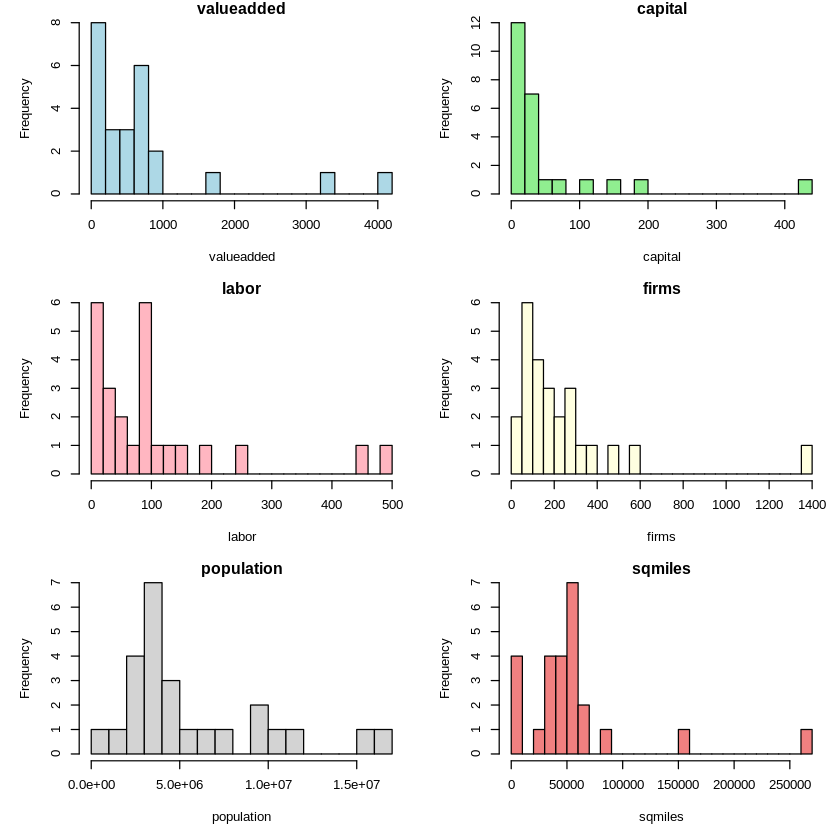

In [14]:
valueadded <- as.numeric(unlist(data['valueadded']))
capital <- as.numeric(unlist(data['capital']))
labor <- as.numeric(unlist(data['labor']))
firms <- as.numeric(unlist(data['firms']))
population <- as.numeric(unlist(data['population']))
sqmiles <- as.numeric(unlist(data['sqmiles']))

par(mfrow = c(3, 2), mar = c(5, 5, 1, 1))
hist(valueadded, main = "valueadded", col = "lightblue", breaks=15)
hist(capital, main = "capital", col = "lightgreen", breaks=30)
hist(labor, main = "labor", col = "lightpink", breaks=30)
hist(firms, main = "firms", col = "lightyellow", breaks=20)
hist(population, main = "population", col = "lightgray", breaks=15)
hist(sqmiles, main = "sqmiles", col = "lightcoral", breaks=20)

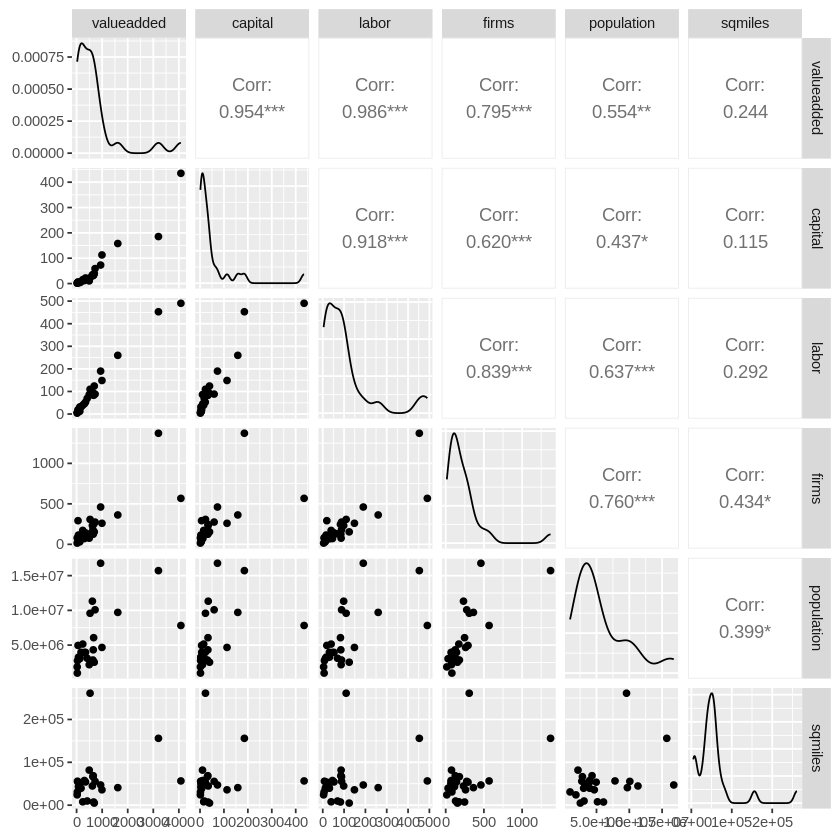

In [18]:
ggpairs(subset(data, select = -c(rownames)))

With the log transformation:

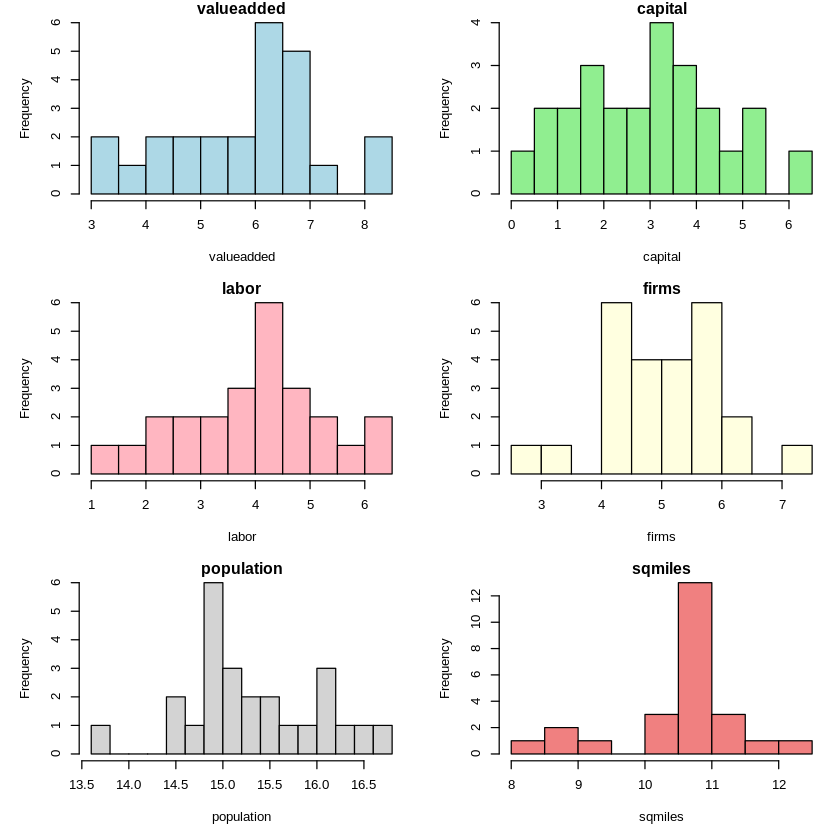

In [21]:
data_logged <- data
data_logged['valueadded'] <- log(data_logged['valueadded'])
data_logged['capital'] <- log(data_logged['capital'])
data_logged['labor'] <- log(data_logged['labor'])
data_logged['firms'] <- log(data_logged['firms'])
data_logged['population'] <- log(data_logged['population'])
data_logged['sqmiles'] <- log(data_logged['sqmiles'])

valueadded <- as.numeric(unlist(data_logged['valueadded']))
capital <- as.numeric(unlist(data_logged['capital']))
labor <- as.numeric(unlist(data_logged['labor']))
firms <- as.numeric(unlist(data_logged['firms']))
population <- as.numeric(unlist(data_logged['population']))
sqmiles <- as.numeric(unlist(data_logged['sqmiles']))

par(mfrow = c(3, 2), mar = c(5, 5, 1, 1))
hist(valueadded, main = "valueadded", col = "lightblue", breaks=15)
hist(capital, main = "capital", col = "lightgreen", breaks=15)
hist(labor, main = "labor", col = "lightpink", breaks=15)
hist(firms, main = "firms", col = "lightyellow", breaks=15)
hist(population, main = "population", col = "lightgray", breaks=12)
hist(sqmiles, main = "sqmiles", col = "lightcoral", breaks=12)

To view the correlations, we can visualize the correlation matrix:

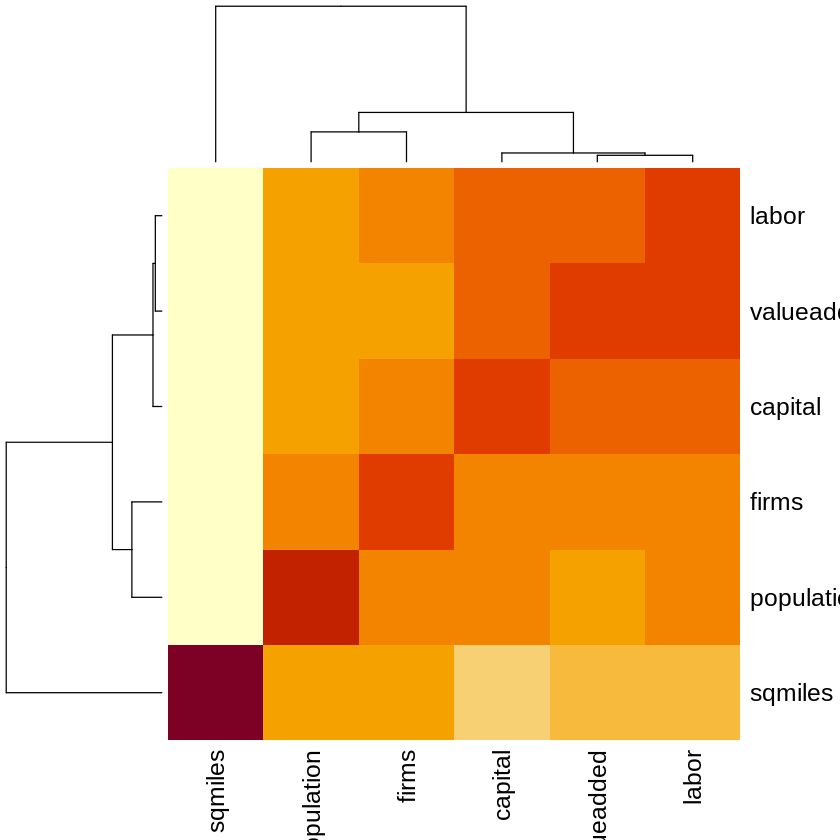

In [ ]:
data_logged <- subset(data_logged, select = -c(rownames))
cormat <- cor(data_logged)
heatmap(cormat)

We may want to view partial correlation, to isolate the dependencies between each pair of variables with the correlation between others removed.

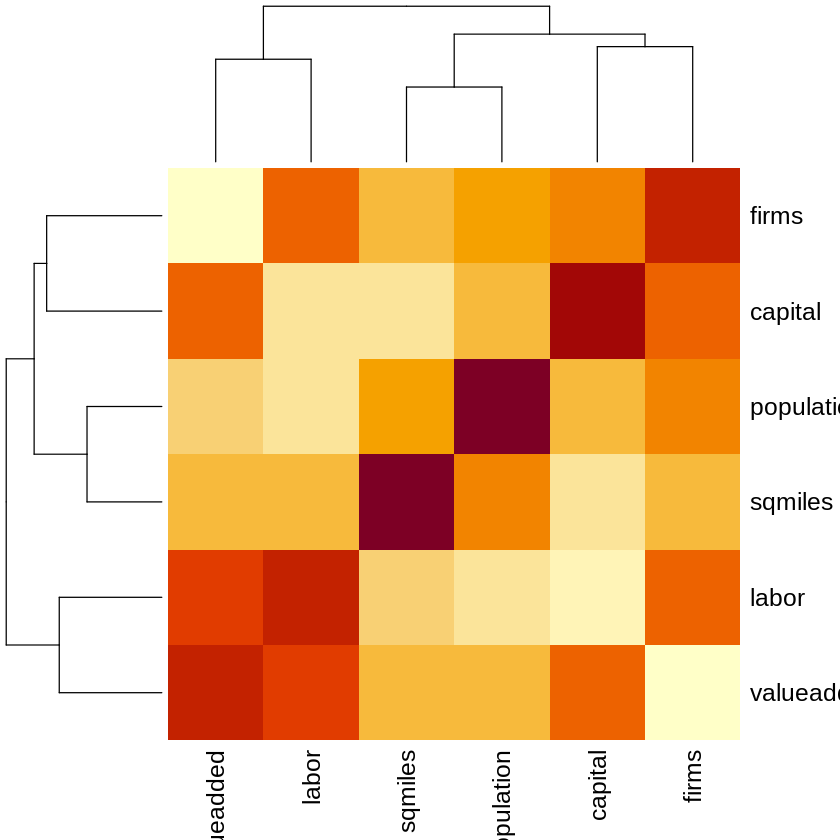

In [ ]:
invcor <- cor2pcor(cormat)
dimnames(invcor) <- dimnames(cormat)
heatmap(invcor)

As expected, the brighter spots have dimmed. We can keep the above in mind when viewing the structures that various algorithms learn from the data.

## Network Learning

The ability to learn relationships between variables from the data is often one of the most attractive aspects of using a BN to model the data. Network structure learning algorithms can be grouped into two categories:

- Constraint-based algorithms learn nework structure by analyzing the probabilistic relations entailed by the Markov property of Baysian networks with conditional independence tests and then constructing a graph which satisfies the corresponding d-separation statements.

- Score-based algorithms assign a score to each candidate BN and try to maximize it with some heuristic search algorithm.

Constraint-based algorithms are based on the Inductive Causation (IC) algorithm by Verma and Pearl (1991), which provides a theoretical framework for learning the structure.

1. The skeleton of the network, the undirected graph underlying the structure, is learned. Learning algorithms use some kind of optimization such as restricting the search of the Markov blanket of each node (the node's parents, plus all parents of its children).

2. Set the direction on arcs that provide a v-structure, $X_j \rightarrow X_i \leftarrow X_k$

3. Set the directions of the other arcs as needed to satisfy the acyclicity constraint.

Score-based algorithms, on the other hand, are applications of general purpose heuristic search algorithms, such as hill-climbing, tabu search, simulated annealing, and genetic algorithms.

We will perform structure learning in the case of both the continuous and hybrid BNs, starting with continuous.

## Network Learning Algorithms

### Constraint-Based Learning Algorithms

- <code>iamb</code>: the Incremental Association method is based on Markov blanket detection, and a two-phase selection scheme involving a forward pass followed by an attempt to remove false positives.

- <code>fast.iamb</code>: a variant of <code>iamb</code> which uses speculative stepwise forward selection to reduce the number of conditional independence tests.

- <code>inter.iamb</code>: Interleaved Incremental Association, another variant of <code>iamb</code>, which uses forward stepwise selection to avoid false positives in the Markov blanket detection process.

- <code>mmpc</code>: Max-Min Parents and Children, a forward selection technique for neighborhood detection based on teh maximization of the minimum association measure

### Score-Based Learning Algorithms

- <code>hc</code>: hill-climbing; a greedy search which explores the space of the DAGs by single-arc addition, removal, and reversals, with random restarts to avoid local optima.

- <code>tabu</code>: a modified hill-climbing algorithm able to escape local optima, by selecting a network that maximally decreases the score function.

### Hybrid Learning Algorithms

- <code>mmhc</code>: Max-Min Parents and Children, a hybrid algorithm which combines the Min-Max Parents and Children algorithm (to restrict search space) and the hill-climbing algorithm (to find the network structure).

- <code>rsmax2</code>: Restricted Maximization, a general implementation of the 'Sparse Condidate' algorithm, which can use a combination of constraint-based and score-based algorithms.

- <code>h2pc</code>: Hybrid HPC, a hybrid algorithms combining the "Hybrid Parents and Children" algorithm with hill-climbing.

There are others, based on various papers that have been published over the years, and an exhaustive list can be found <a href="https://www.rdocumentation.org/packages/bnlearn/versions/5.0/topics/structure-learning">here</a> if interested.

We'll let the various algorithms learn the network without any assistance starting with <code>iamb</code>.

In [ ]:
learned_iamb <- iamb(data_logged, test = "cor")
learned_iamb


  Bayesian network learned via Constraint-based methods

  model:
    [undirected graph]
  nodes:                                 6 
  arcs:                                  4 
    undirected arcs:                     4 
    directed arcs:                       0 
  average markov blanket size:           1.33 
  average neighbourhood size:            1.33 
  average branching factor:              0.00 

  learning algorithm:                    IAMB 
  conditional independence test:         Pearson's Correlation 
  alpha threshold:                       0.05 
  tests used in the learning procedure:  91 


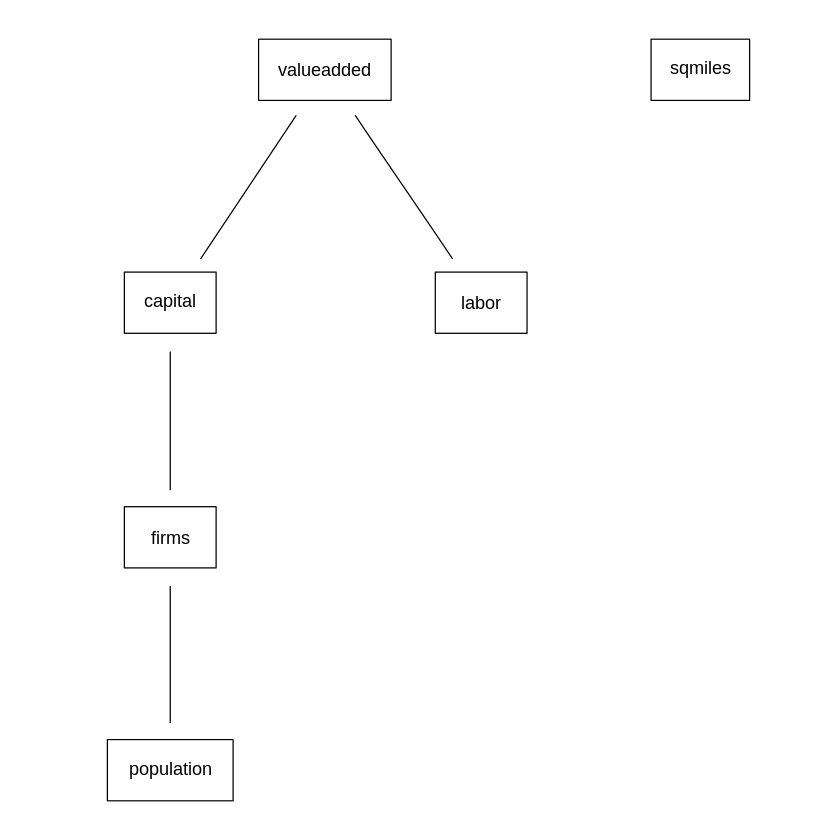

In [ ]:
graphviz.plot(learned_iamb)

Notice the lack of arrow on the edges; they are undirected. <code>iamb</code> wasn't confident enough to set any directions, and we will be unable to fit this network to data unless they are constructed.

Next, the <code>h2pc</code> algorithm:

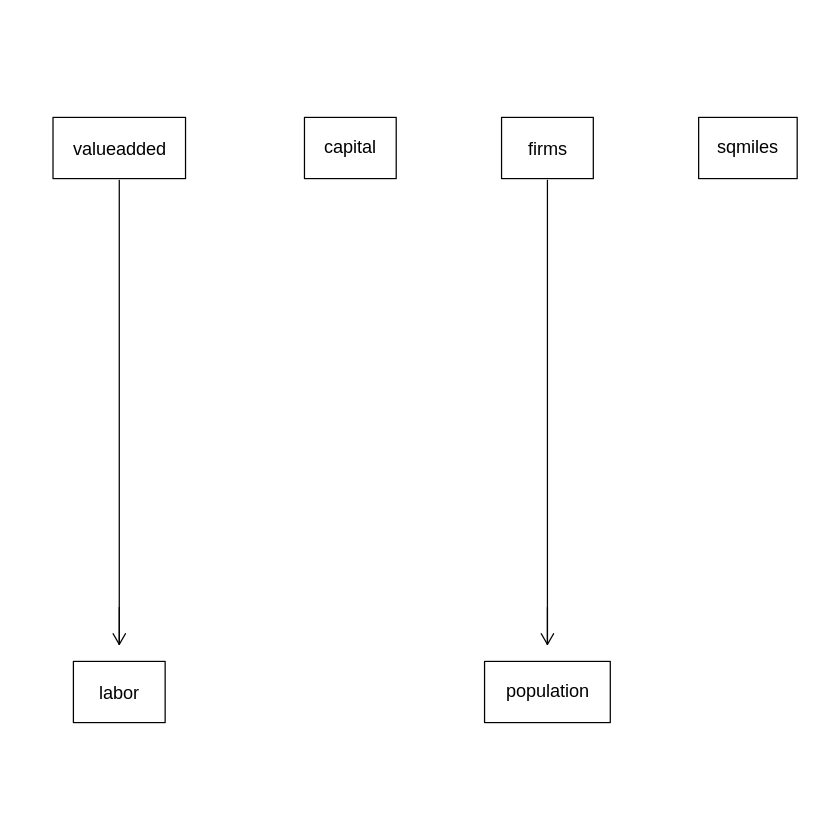

In [ ]:
learned_h2pc <- h2pc(data_logged)
graphviz.plot(learned_h2pc)

We see that it found that less connections were important. Next, we'll try hill-climbing.

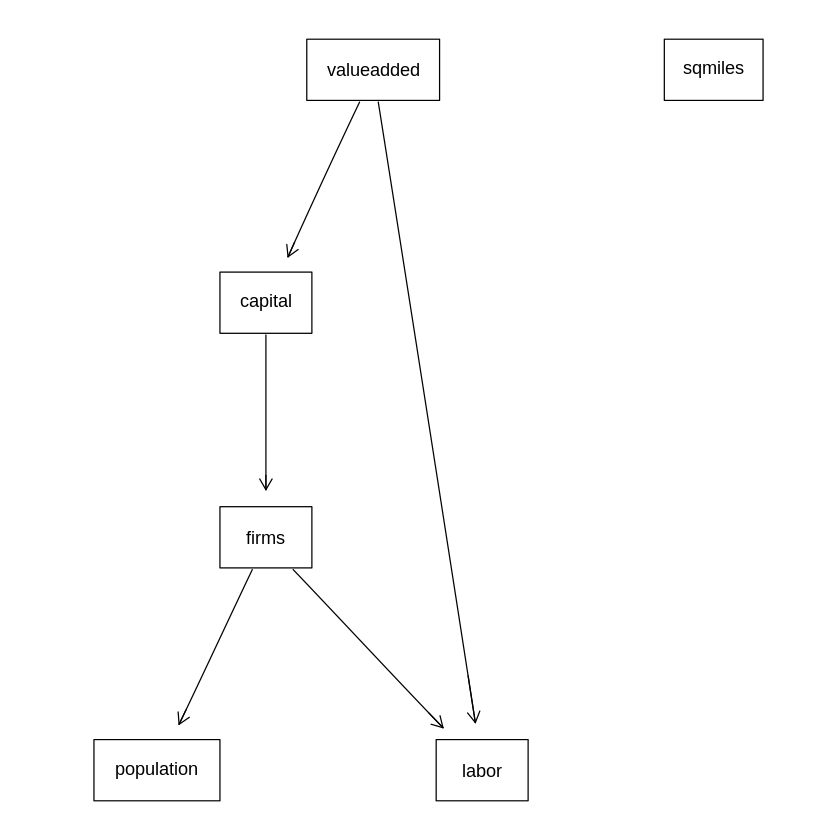

In [ ]:
learned_hc <- hc(data_logged)
graphviz.plot(learned_hc)

Interesting, we have three different structures thus far... how about <code>rsmax2</code>?

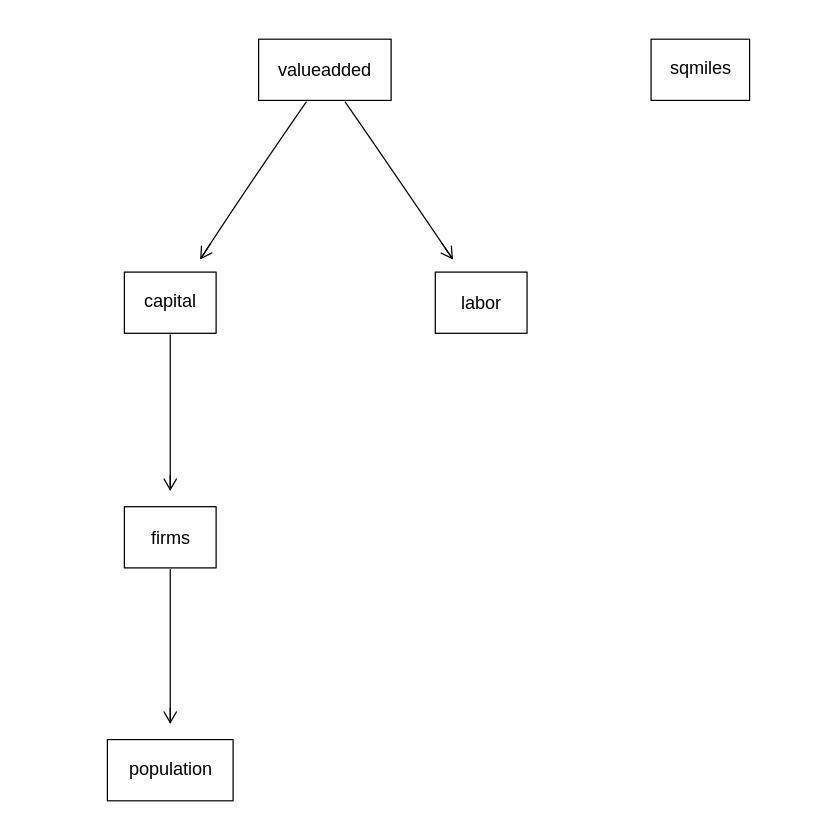

In [ ]:
learned_rsmax2 <- rsmax2(data_logged, maximize = "hc")
graphviz.plot(learned_rsmax2)

It has reproduced the result of the <code>iamb</code> algorithm, but added directions.

I will use more of the available algorithms later, upon different data, but from playing around, I know that on this data they will produce structures equal to the ones above. To evaluate, we can score against the data using <code>type="bic-g"</code>, a continuous version of the BIC score.

In [ ]:
paste("h2pc   ", round(score(learned_h2pc, data_logged, type = "bic-g"),2))
paste("hc     ", round(score(learned_hc, data_logged, type = "bic-g"),2))
paste("rsmax2 ", round(score(learned_rsmax2, data_logged, type = "bic-g"),2))

[1] "h2pc    -188.15"

[1] "hc      -140.51"

[1] "rsmax2  -144.93"

Lower is better, so <code>h2pc</code> does best. We can use <code>by.node=TRUE</code> to view the score for each node, and compare <code>learned_h2pc</code> to the next-best scoring DAG to see if it also scores better node-wise.

In [ ]:
round(score(learned_h2pc, data_logged, type = "bic-g", by.node=TRUE),2)
round(score(learned_rsmax2, data_logged, type = "bic-g", by.node=TRUE),2)

valueadded    capital      labor      firms population    sqmiles 
    -46.16     -47.96      -2.92     -36.85     -18.64     -35.61

valueadded    capital      labor      firms population    sqmiles 
    -46.16     -17.49      -2.92     -24.11     -18.64     -35.61

We see that it does. But there is a catch, and I'll re-plot the DAG below to remind us what it looks like.

There are fewer connections in this DAG, which can push down the BIC score, but to have certain variables not be part of the network, we lose out on the ability to predict them, along with any predictive power they lend toward other variables.

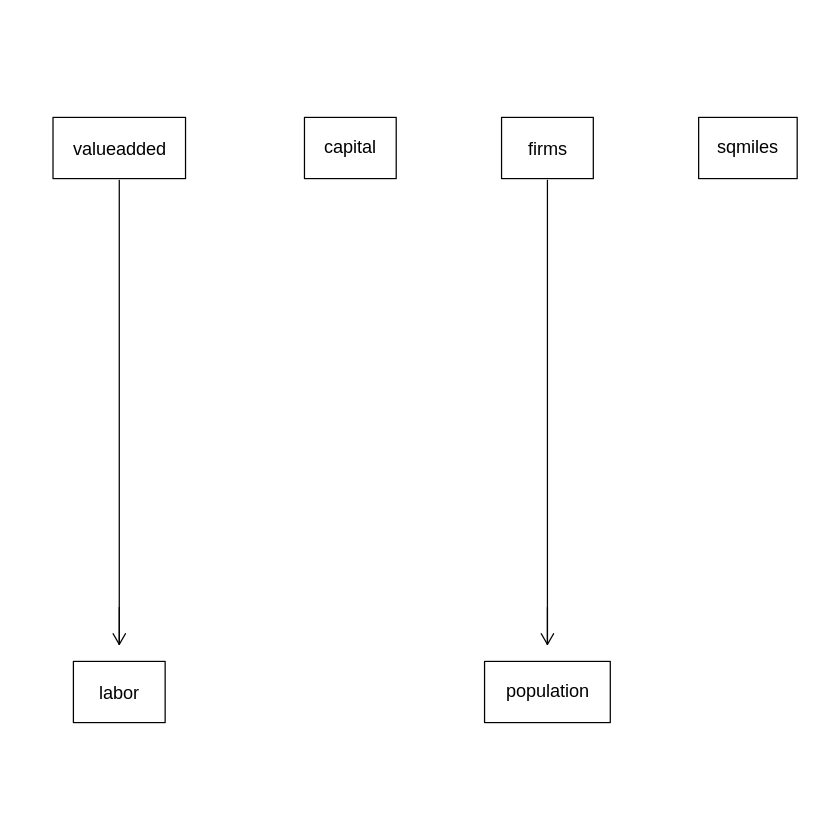

In [ ]:
graphviz.plot(learned_h2pc)

### Whitelisting and Blacklisting

Let's give the model some help; there are reasonable assumptions that we can try, and then validate. We can force associations with a <code>whitelist</code>, or prohibit associations with a <code>blacklist</code>. With those connections (or lack of) fixed, we may well see different relationships involving the other nodes.

Currently, we have <code>valueadded</code> pointed toward <code>labor</code>, and that seems like perhaps it should be the reverse. Also, the number of <code>firms</code> likely doesn't determine the level of <code>population</code>. We'll prohibit both of these with a blacklist.

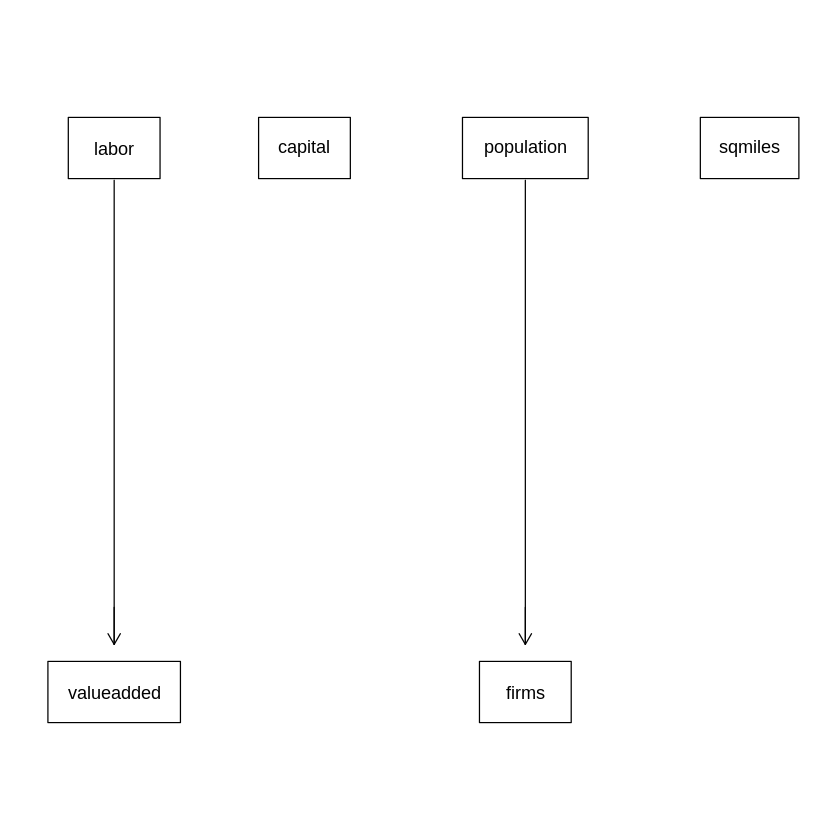

In [ ]:
bl <- matrix(c("valueadded", "labor",
               "firms", "population"), ncol = 2, nrow = 2, byrow=TRUE)

bl_h2pc <- h2pc(data_logged, blacklist = bl)
graphviz.plot(bl_h2pc)

Let's try an algorithm that's a little more prone to making connections, given the data. We'll use the hill-climbing algorithm.

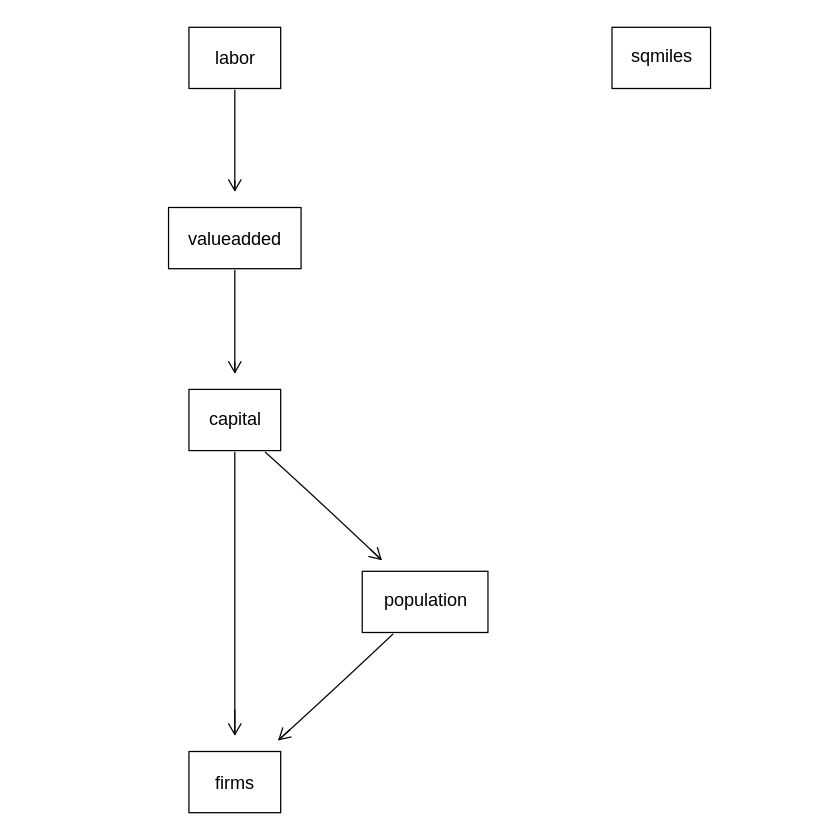

In [ ]:
bl_hc <- hc(data_logged, blacklist=bl)
graphviz.plot(bl_hc)

Better, but still fails to fit with intuition in several ways. Likely the <code>population</code> should not be downstream of firm capital. Also, the goal of analyzing this dataset would likely be to model <code>valueadded</code>, and yet it is disconnected or upstream of all but one variable.

So we'll blacklist any variable from being downstream of <code>valueadded</code>, and we'll blacklist certain variables from being upstream of <code>population</code>.

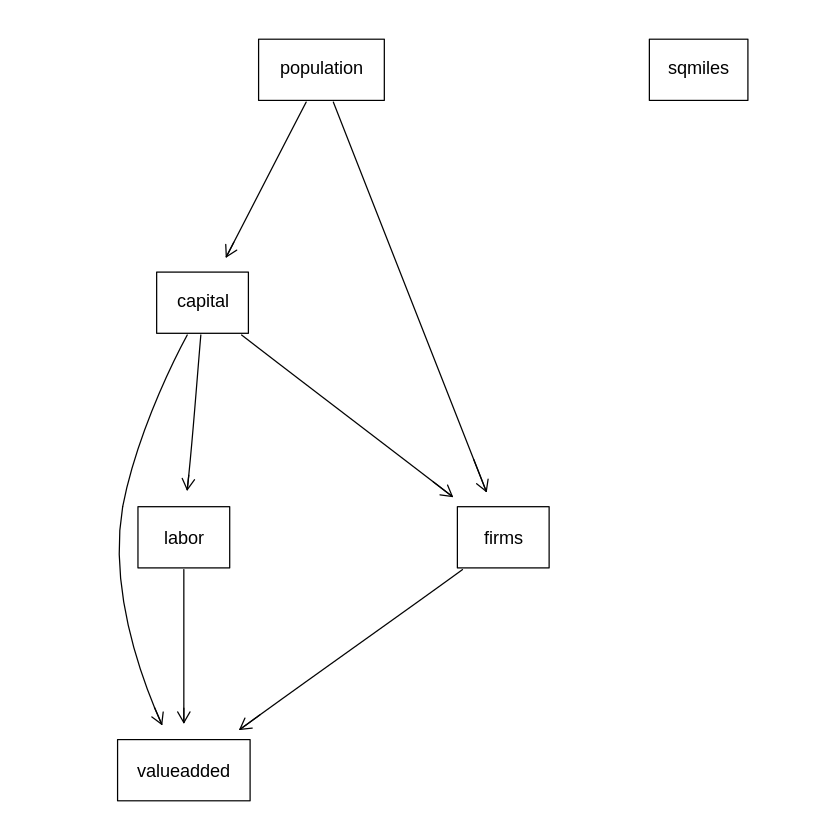

In [ ]:
bl <- matrix(c("valueadded", "labor",
               "valueadded", "capital",
               "valueadded", "population",
               "valueadded", "firms",
               "valueadded", "sqmiles",
               "firms", "population",
               "capital", "population",
               "labor", "population"), ncol = 2, nrow = 8, byrow=TRUE)

bl_hc <- hc(data_logged, blacklist = bl)
graphviz.plot(bl_hc)

This looks quite reasonable. We can score it against the models created earlier:

In [ ]:
paste("bl_hc  ", round(score(bl_hc, data_logged, type = "bic-g"),2))
paste("hc     ", round(score(learned_hc, data_logged, type = "bic-g"),2))
paste("rsmax2 ", round(score(learned_rsmax2, data_logged, type = "bic-g"),2))

[1] "bl_hc   -142"

[1] "hc      -140.51"

[1] "rsmax2  -144.93"

It scores quite low; not the lowest, but note that it has 7 arcs, whereas the other models have fewer. It's also more intuitively sensible, and likely of greater predictive value.

In [ ]:
narcs(bl_hc)
narcs(learned_hc)
narcs(learned_rsmax2)

[1] 7

[1] 5

[1] 4

We can also run cross-validation, such as to see whether we can improve our model by setting an arc from our stray variable <code>sqmiles</code> to the item <code>capital</code>, which it has a high partial correlation with. I'll make a third model where it is connected to <code>firms</code>, and a fourth model where it is connected to both.

In [ ]:
bl_hc2 <- set.arc(bl_hc, "sqmiles", "capital")
bl_hc3 <- set.arc(bl_hc, "sqmiles", "firms")
bl_hc4 <- set.arc(bl_hc, "sqmiles", "capital")
bl_hc4 <- set.arc(bl_hc4, "sqmiles", "firms")

In [ ]:
narcs(bl_hc)
narcs(bl_hc2)
narcs(bl_hc3)
narcs(bl_hc4)

[1] 7

[1] 8

[1] 8

[1] 9

In [ ]:
seed <- 1234
bn.cv(data_logged, bl_hc, method = "k-fold", k=25)
bn.cv(data_logged, bl_hc2, method = "k-fold", k=25)
bn.cv(data_logged, bl_hc3, method = "k-fold", k=25)
bn.cv(data_logged, bl_hc4, method = "k-fold", k=25)


  k-fold cross-validation for Bayesian networks

  target network structure:
   [population][sqmiles][capital|population][labor|capital]
   [firms|capital:population][valueadded|capital:labor:firms]
  number of folds:                       25 
  loss function:                         Log-Likelihood Loss (Gauss.) 
  expected loss:                         5.495423 



  k-fold cross-validation for Bayesian networks

  target network structure:
   [population][sqmiles][capital|population:sqmiles][labor|capital]
   [firms|capital:population][valueadded|capital:labor:firms]
  number of folds:                       25 
  loss function:                         Log-Likelihood Loss (Gauss.) 
  expected loss:                         5.51703 



  k-fold cross-validation for Bayesian networks

  target network structure:
   [population][sqmiles][capital|population][labor|capital]
   [firms|capital:population:sqmiles][valueadded|capital:labor:firms]
  number of folds:                       25 
  loss function:                         Log-Likelihood Loss (Gauss.) 
  expected loss:                         5.495432 



  k-fold cross-validation for Bayesian networks

  target network structure:
   [population][sqmiles][capital|population:sqmiles][labor|capital]
   [firms|capital:population:sqmiles][valueadded|capital:labor:firms]
  number of folds:                       25 
  loss function:                         Log-Likelihood Loss (Gauss.) 
  expected loss:                         5.517039 


Lower values of the log-likelihood loss metric are better, so with the random seed I've chosen, the first and third model tie for best, though the other two aren't far behind.

## Fitting to Data

We'll fit data to the third model.

In [ ]:
fitted = bn.fit(bl_hc3, data_logged)

Just as we could call up the conditional probability table for a node when using a discrete network, the continuous network allows us to call upon nodes in order to view the coefficient values of the parents, along with the intercept.

In [ ]:
fitted$valueadded


  Parameters of node valueadded (Gaussian distribution)

Conditional density: valueadded | capital + labor + firms
Coefficients:
(Intercept)      capital        labor        firms  
  2.6956594    0.3329967    0.8817093   -0.2814052  
Standard deviation of the residuals: 0.1829037 

These coefficients can be pulled out and worked with through indexing.

In [ ]:
fitted$valueadded$coefficients[1]
fitted$valueadded$coefficients[2]
fitted$valueadded$coefficients[3]

(Intercept) 
   2.695659

capital 
0.3329967

labor 
0.8817093

The <code>rbmn</code> library offers some tools for working with continuous networks. The below is a table of coefficients among variables in the same format as a correlation matrix, with the first couple columns showing the global means and standard deviations for each variable.

We can use the <code>rbn</code> function to simulate data from the network as follows:

In [ ]:
sim_data_small <- rbn(fitted, n = 200)
sim_data_large <- rbn(fitted, n = 20000)
head(sim_data_large)

,valueadded,capital,labor,firms,population,sqmiles
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,8.546539,6.3984447,6.569403,7.018565,16.67239,12.125044
2,3.939439,0.8528334,2.513568,4.589850,13.79645,10.833452
3,5.814791,2.9004989,3.792399,5.252981,15.88704,12.139265
4,5.846601,2.9033636,3.915669,5.331328,15.33025,10.455398
5,5.325315,1.9174193,3.549875,4.921728,15.01449,8.743004
6,8.093812,5.5470117,5.965563,6.276549,16.23023,11.052689


## Inspecting and Querying

We can use the <code>cpquery</code> function of <code>bnlearn</code> to ask about the probability of a particular evident given some evidence, such as the chance of <code>valueadded</code> being above average for states with a greater number of <code>firms</code> than average.

In [ ]:
cpquery(fitted, event = (valueadded > mean(data_logged$valueadded)),
        evidence = (firms > mean(data_logged$firms)))

[1] 0.7615508

The <code>cpdist</code> function will not output a conditional probability table like when we were working with discrete data, but rather the value of a variable at given quantiles, given the query and evidence. Below queries the values of <code>valueadded</code> conditional upon number of <code>firms</code> being greater than average.

In [ ]:
part <- cpdist(fitted, nodes="valueadded", evidence = (firms >= mean(data_logged$firms)), n = 10^5)
summary(part$valueadded)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  1.804   5.818   6.578   6.603   7.360  11.309 

## <u>Hybrid Networks (CGBNs)</u>

In the case of hybrid data and conditional GBNs (CGBNs), the nature of each node and its parents determine the form of the parameters of the local distribution. If a node is discrete, it may only have discrete parents, and the parameters of its local distribution are in the form of a conditional probability table. Continuous nodes with continuous parents involve a regression coefficient and standard deviation of residuals, as with GBNs, and continuous nodes with discrete parents receive one set of regression coefficients and one standard deviation for each configuration of the discrete parent.

This calls for a new dataset. I've chosen the bike rentals dataset available in the <code>bayesrules</code> package of R (based on the free online <a href="https://www.bayesrulesbook.com/">book</a>), but have preprocessed it so that we don't have to deal with those details. For example, the hour of day field has been binned, and combined with day-of-week to capture interaction between the two. The original hour and weekday fields have been dropped.

Fields of the preprocessed data that we will use include:

- <code>weather_cat</code>: state of weather: Pleasant, Moderate, or Severe
- <code>date_idx</code>: number of days since the start of measurement
- <code>holiday</code>: binary, whether it is a holiday
- <code>humidity</code>: level of humidity
- <code>rides</code>: number of bikes rented that hour
- <code>season</code>: season of year
- <code>temp_actual</code>: the actual temperature outside
- <code>temp_feel</code>: the perceived temperature outside
- <code>windspeed</code>: current windspeed

In [ ]:
data <- read.csv("https://raw.githubusercontent.com/pw598/Articles/main/data/bikes.csv")

data['season'] <- as.factor(data$season)
data['hour'] <- as.factor(data$hour)
data['holiday'] <- as.factor(data$holiday)
data['weather_cat'] <- as.factor(data$weather_cat)
data['rides'] <- as.numeric(data$rides)

The timespan is approximately two years. A plot reveals that there is definitely a seasonal component, as well as growth over time.

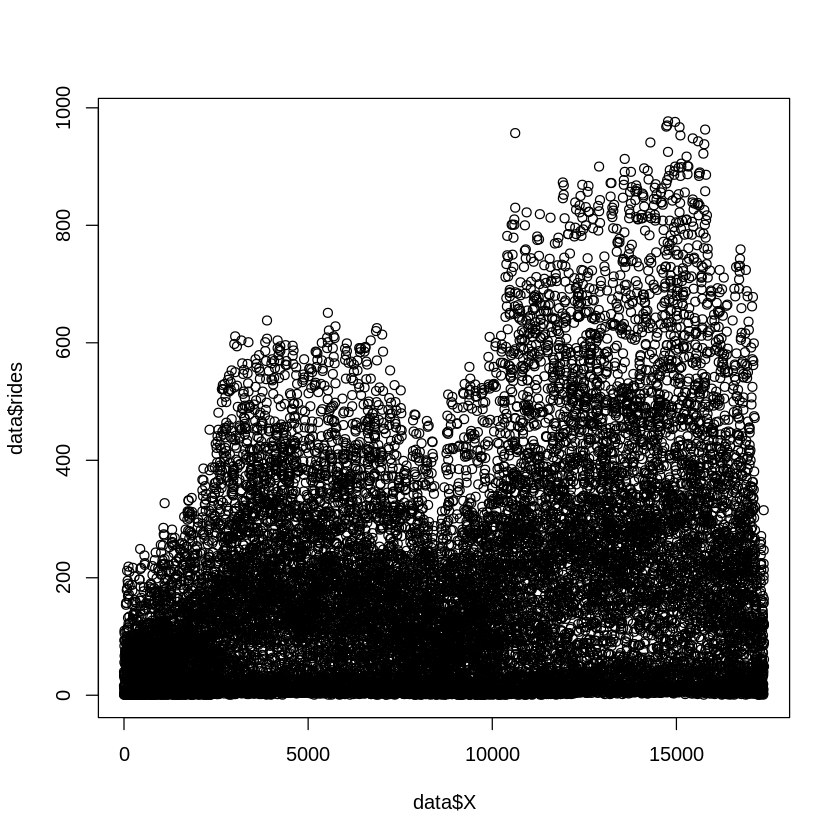

In [ ]:
plot(data$X, y=data$rides)

I'll trim the dataset down to the columns we'll be working with:

In [ ]:
data <- subset(data, select = -c(X, date, year, workingday, month, weekday))
head(data)

,season,hour,holiday,weather_cat,temp_feel,temp_actual,humidity,windspeed,rides,date_idx
,<fct>,<fct>,<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,Winter,Wkdy 0-6,0,Pleasant,0.22,0.1970,0.44,0.3582,5,3
2,Winter,Wkdy 0-6,0,Pleasant,0.20,0.1667,0.44,0.4179,2,3
3,Winter,Wkdy 0-6,0,Pleasant,0.16,0.1364,0.47,0.3881,1,3
4,Winter,Wkdy 0-6,0,Pleasant,0.16,0.1364,0.47,0.2836,3,3
5,Winter,Wkdy 0-6,0,Pleasant,0.14,0.1061,0.50,0.3881,30,3
6,Winter,Wkdy 7,0,Pleasant,0.14,0.1364,0.50,0.1940,64,3


## Network Learning

Let's jump right into learning the network. We have many options in terms of algorithms:

In [ ]:
learned_hc <- hc(data)
learned_mmhc <- mmhc(data)
learned_h2pc <- h2pc(data)
learned_rsmax2 <- rsmax2(data) # generates floating-pt related warnings that I have cleared
learned_tabu <- tabu(data)

And then take a peek at the nodes and arcs discovered.

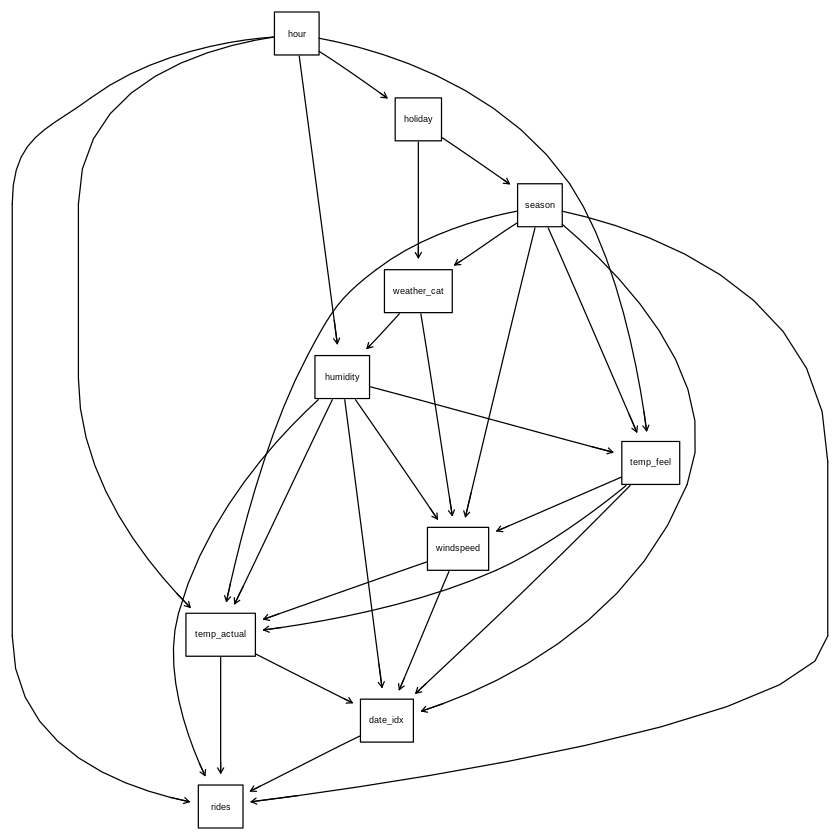

In [ ]:
graphviz.plot(learned_hc)

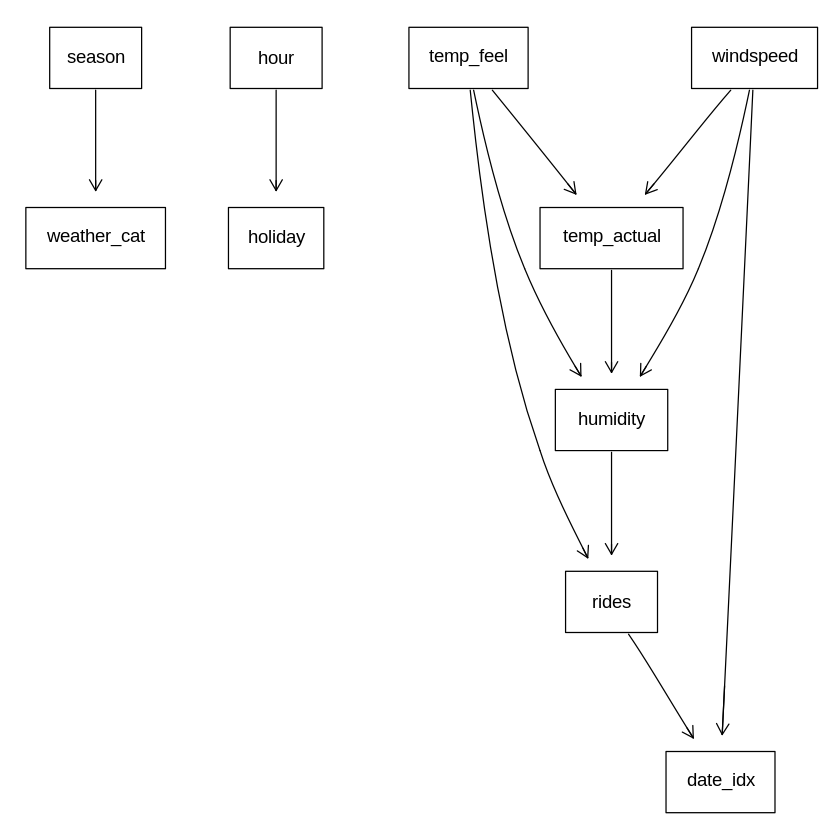

In [ ]:
graphviz.plot(learned_mmhc)

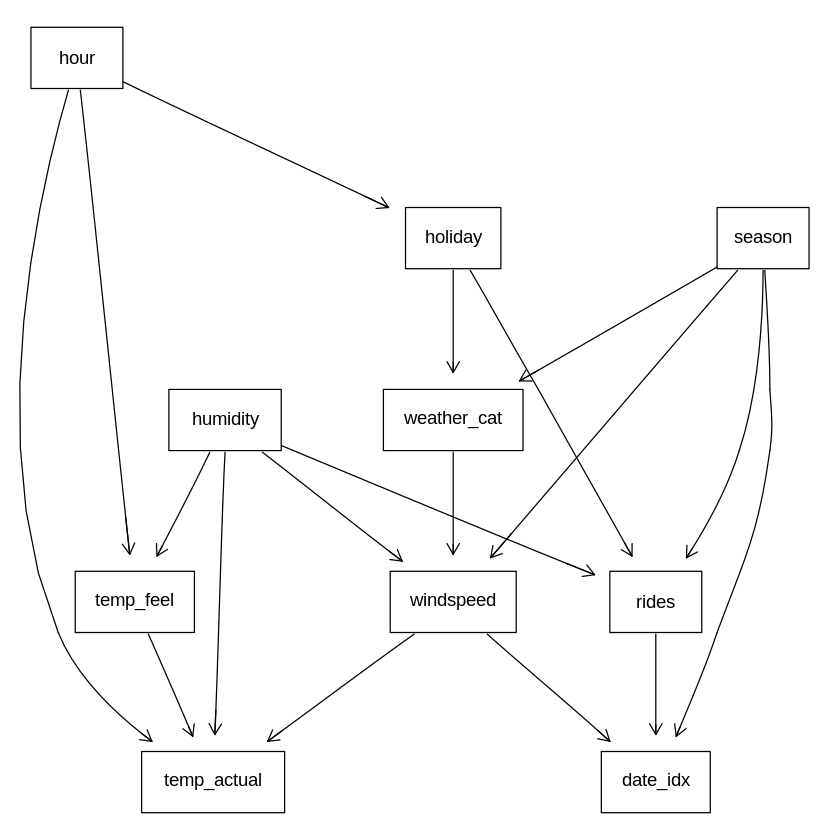

In [ ]:
graphviz.plot(learned_h2pc)

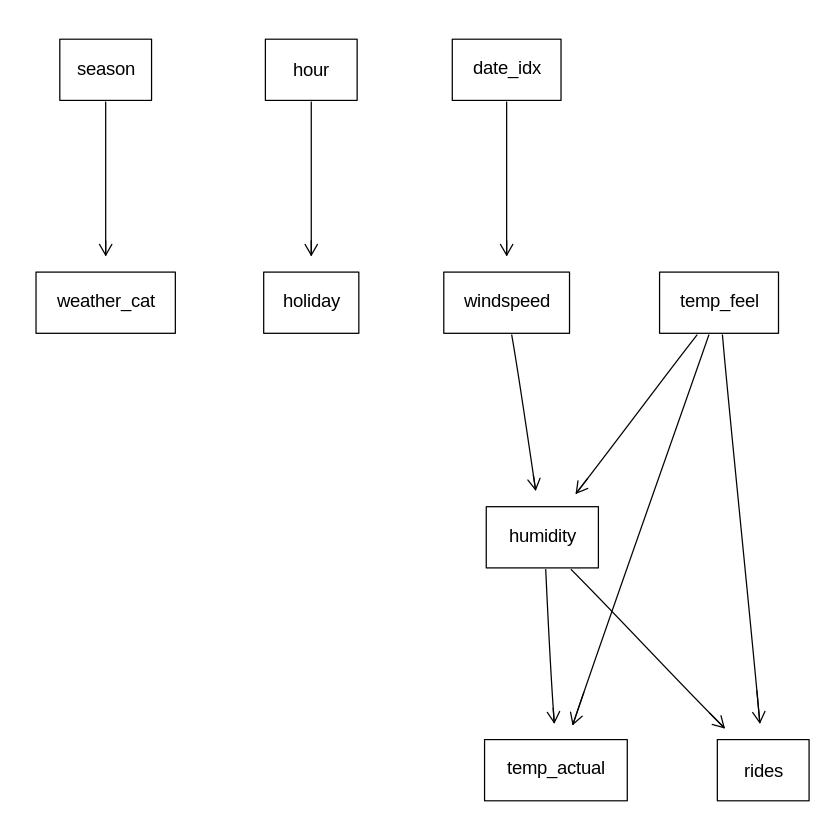

In [ ]:
graphviz.plot(learned_rsmax2)

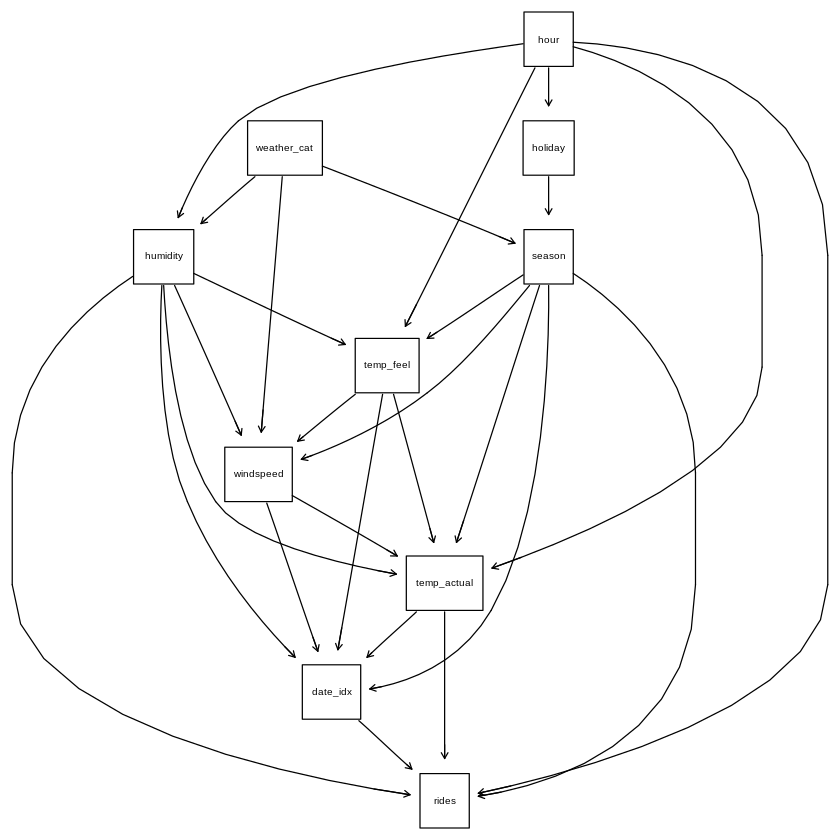

In [ ]:
graphviz.plot(learned_tabu)

Quite a bit of variety. Let's check the BIC scores. For hybrid data, we'll use <code>type="bic-cg"</code>.

In [ ]:
print(paste("hc     ", round(score(learned_hc, data, type = "bic-cg"),0)))
print(paste("mmhc   ", round(score(learned_mmhc, data, type = "bic-cg"),0)))
print(paste("h2pc   ", round(score(learned_h2pc, data, type = "bic-cg"),0)))
print(paste("rsmax2 ", round(score(learned_rsmax2, data, type = "bic-cg"),0)))
print(paste("tabu   ", round(score(learned_tabu, data, type = "bic-cg"),0)))

[1] "hc      -213739"
[1] "mmhc    -249882"
[1] "h2pc    -246792"
[1] "rsmax2  -251097"
[1] "tabu    -213735"


<code>learned_rsmax2</code> has the lowest score, however it and <code>learned_mmhc</code> have the sparsest connections. <code>learned_h2pc</code> does well with a more complete structure, so let's plot it below and then criticize it.

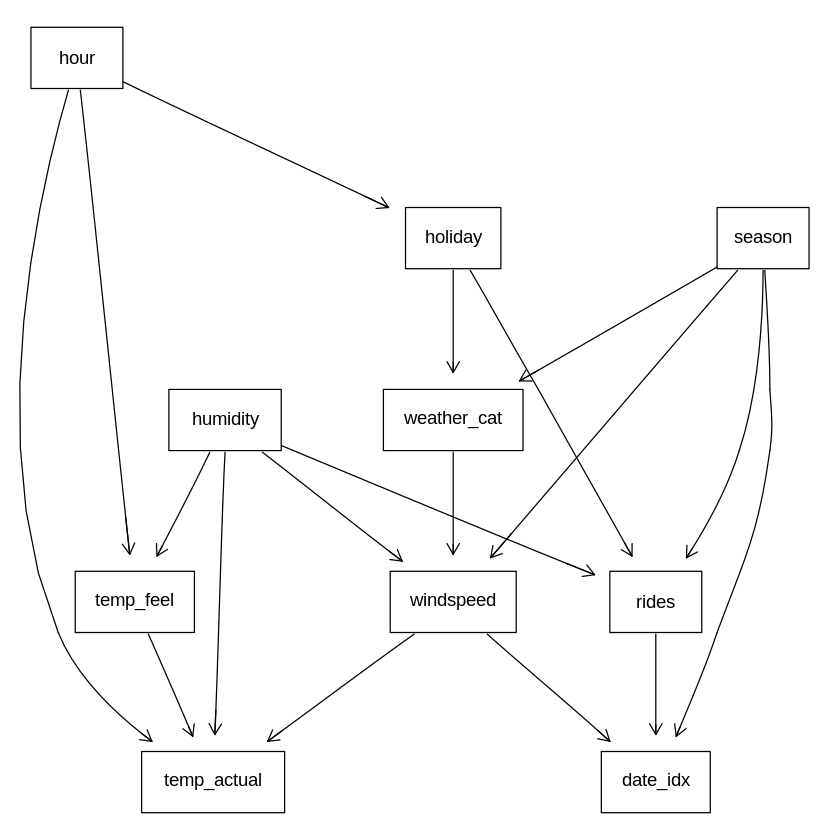

In [ ]:
graphviz.plot(learned_h2pc)

Number of <code>rides</code> is ultimately our target variable, and so we would likely want to restructure things so that it is more downstream in general. Multiple items are pointing to the <code>date_idx</code>, and clearly we would want things to be dependent upon time, rather than vice versa. The <code>season</code> to <code>date_idx</code> connection is also not logical. Furthermore, the hour of day should not affect whether it's a holiday (though the day of week component integrated during preprocessing would), and whether it is a holiday should not affect the weather category, as the DAG is suggesting.

### Whitelisting and Blacklisting

To do things differently from above, and save a little time, we'll start by whitelisting items we would like to see rather than blacklist those we don't, and deal with any unwanted or unintuitive connections by subsequently blacklisting or removing arcs.

In [ ]:
wl <- matrix(c("date_idx", "rides",
               "season", "temp_actual",
               "weather_cat", "temp_actual",
               "weather_cat", "temp_feel",
               "weather_cat", "windspeed",
               "temp_actual", "windspeed",
               "temp_actual", "humidity",
               "temp_actual", "temp_feel",
               "humidity", "temp_feel",
               "windspeed", "temp_feel",
               "temp_feel", "rides",
               "hour", "rides",
               "holiday", "rides",
               "date_idx", "rides"), ncol = 2, nrow = 14, byrow=TRUE)

wl_h2pc <- h2pc(data, whitelist = wl) # there were floating-pt related warnings which I have cleared

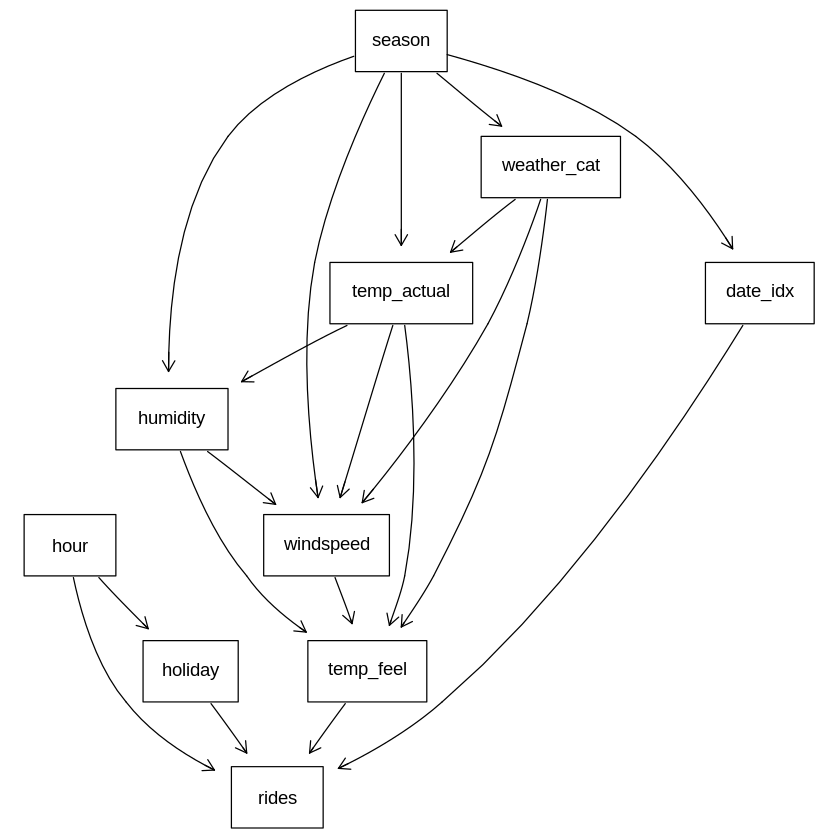

In [ ]:
graphviz.plot(wl_h2pc)

Not bad, but we have <code>hour</code> pointing toward <code>holiday</code> and season pointing toward <code>date_idx</code>. I will simply drop these.

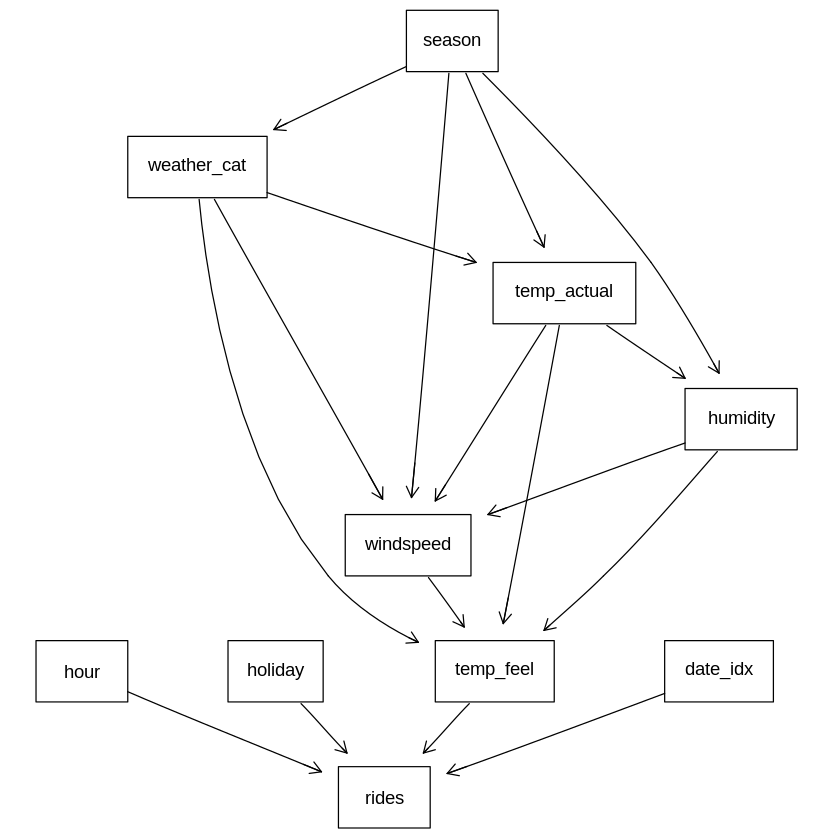

In [ ]:
new_dag <- drop.arc(wl_h2pc, "hour", "holiday")
new_dag <- drop.arc(new_dag, "season", "date_idx")
graphviz.plot(new_dag)

We can use the <code>arc.strength</code> function to get a table of strength values for each connection. For <code>bic-cg</code>, lower values indicate greater strength.

In [ ]:
df <- arc.strength(new_dag, data, criterion='bic-cg')
df[order(-df$strength, decreasing = TRUE), ]

,from,to,strength
,<chr>,<chr>,<dbl>
8,temp_actual,temp_feel,-32650.56242
2,hour,rides,-15426.19811
1,season,temp_actual,-7993.77762
7,temp_feel,rides,-2671.12251
13,date_idx,rides,-2413.65358
15,season,humidity,-986.81482
14,humidity,windspeed,-895.81901
9,temp_actual,humidity,-744.49442
12,windspeed,temp_feel,-369.61861


We can try trimming away the arcs with the lowest strength levels, and view the impact on overall model score.

In [ ]:
fewer_arcs <- new_dag
fewer_arcs <- drop.arc(fewer_arcs, "humidity", "temp_feel")
fewer_arcs <- drop.arc(fewer_arcs, "weather_cat", "temp_feel")
fewer_arcs <- drop.arc(fewer_arcs, "season", "weather_cat")
fewer_arcs <- drop.arc(fewer_arcs, "temp_actual", "windspeed")

In [ ]:
round(score(new_dag, data, type = "bic-cg"),2)
round(score(fewer_arcs, data, type = "bic-cg"),2)

[1] -225996.8

[1] -226104.9

The DAG with fewer arcs has scored better.

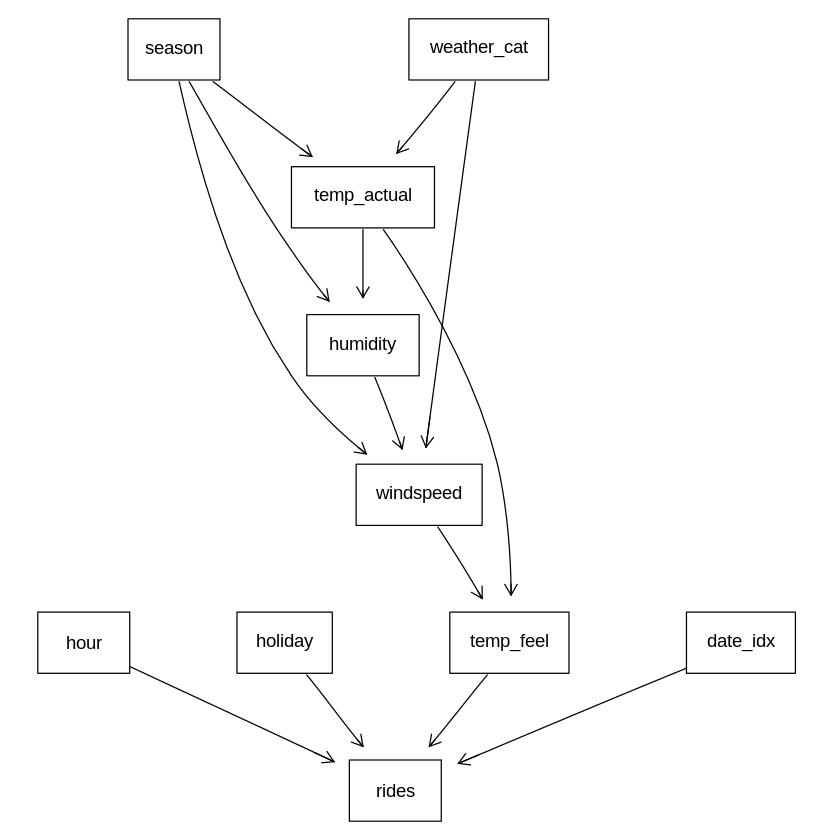

In [ ]:
graphviz.plot(fewer_arcs)

I'm a little dubious of the <code>humidity</code> to <code>windspeed</code> relationship. I think it would make more sense that <code>humidity</code> affects <code>temp_feel</code> more. I'll try making the change and evaluate the difference empirically using cross-validation.

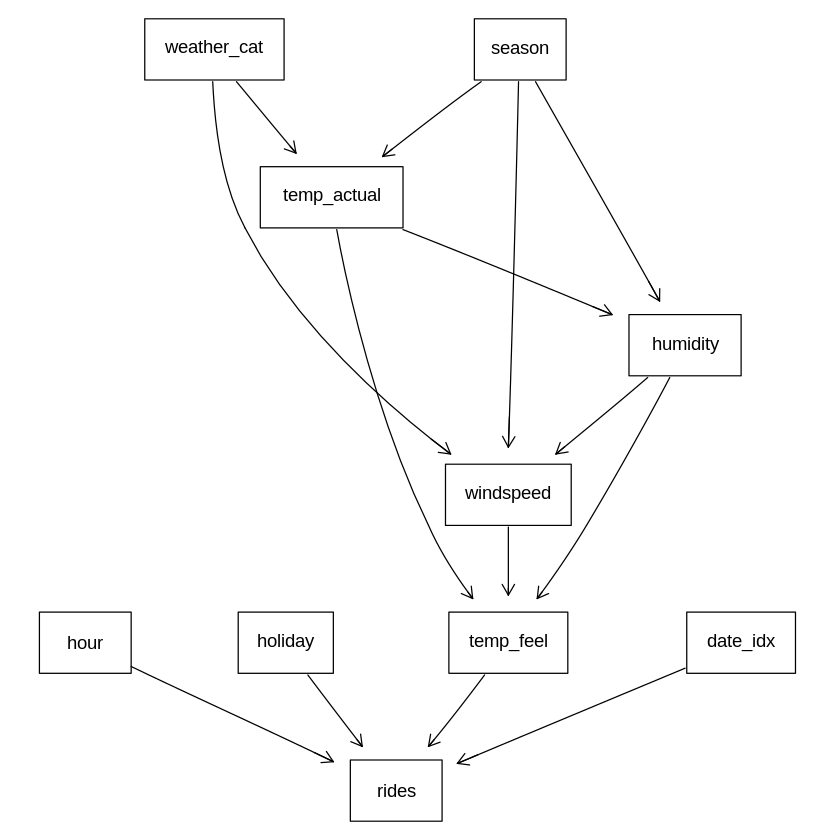

In [ ]:
fewer_arcs2 <- fewer_arcs
fewer_arcs2 <- drop.arc(fewer_arcs, "humidity", "windspeed")
fewer_arcs2 <- set.arc(fewer_arcs, "humidity", "temp_feel")
graphviz.plot(fewer_arcs2)

In [ ]:
seed <- 1234
bn.cv(data, fewer_arcs, method = "k-fold", k=25)
bn.cv(data, fewer_arcs2, method = "k-fold", k=25)


  k-fold cross-validation for Bayesian networks

  target network structure:
   [season][hour][holiday][weather_cat][date_idx]
   [temp_actual|season:weather_cat][humidity|season:temp_actual]
   [windspeed|season:weather_cat:humidity][temp_feel|temp_actual:windspeed]
   [rides|hour:holiday:temp_feel:date_idx]
  number of folds:                       25 
  loss function:                         Log-Likelihood Loss (cond. Gauss.) 
  expected loss:                         12.97457 



  k-fold cross-validation for Bayesian networks

  target network structure:
   [season][hour][holiday][weather_cat][date_idx]
   [temp_actual|season:weather_cat][humidity|season:temp_actual]
   [windspeed|season:weather_cat:humidity]
   [temp_feel|temp_actual:humidity:windspeed]
   [rides|hour:holiday:temp_feel:date_idx]
  number of folds:                       25 
  loss function:                         Log-Likelihood Loss (cond. Gauss.) 
  expected loss:                         12.97332 


With the random seed I've chosen, the DAG with the change has performed slightly better.

As before, we can do conditional independence testing, such as by using the correlation test below. We see that <code>humidity</code> and <code>windspeed</code> have moderate correlation, but <code>humidity</code> and <code>temp_feel</code> do not. The p-values are very low, but that speaks toward the size of the dataset more than strength of effect.

In [ ]:
ci.test("humidity", "windspeed", test = "cor", data = data)


	Pearson's Correlation

data:  humidity ~ windspeed  
cor = -0.29021, df = 17374, p-value < 2.2e-16
alternative hypothesis: true value is not equal to 0


In [ ]:
ci.test("humidity", "temp_feel", test = "cor", data = data)


	Pearson's Correlation

data:  humidity ~ temp_feel  
cor = -0.069542, df = 17374, p-value < 2.2e-16
alternative hypothesis: true value is not equal to 0


## Inspecting and Querying

As before, we can call upon nodes of the fitted DAG to view parameter values.

In [ ]:
fitted <- bn.fit(new_dag, data)
fitted$temp_actual


  Parameters of node temp_actual (conditional Gaussian distribution)

Conditional density: temp_actual | season + weather_cat
Coefficients:
                     0          1          2          3          4          5
(Intercept)  0.4265332  0.5040137  0.6368571  0.3010280  0.4083235  0.5363395
                     6          7          8          9         10         11
(Intercept)  0.6658887  0.2968593  0.4313939  0.4559241  0.6028747  0.2985924
Standard deviation of the residuals:
         0           1           2           3           4           5  
0.10369574  0.11525822  0.08387444  0.10578255  0.11299603  0.12296326  
         6           7           8           9          10          11  
0.08935074  0.12004442  0.09660610  0.12149943  0.08081015  0.09876843  
Discrete parents' configurations:
    season  weather_cat
0     Fall     Moderate
1   Spring     Moderate
2   Summer     Moderate
3   Winter     Moderate
4     Fall     Pleasant
5   Spring     Pleasant
6   Summer     P

## Approximate Inference

The <code>cpquery</code> function can be used to make approximate inference by generating samples. For example, the following queries the probability of <code>rides</code> being greater than 200 given that the <code>season</code> is Summer and the actual temperature is greater than average.

In [ ]:
cpquery(fitted, event = (rides > 200),
        evidence = (season == "Summer") & (temp_actual > mean(data$temp_actual)), n = 10^5)

[1] 0.5117153

Similarly, we can use the <code>cpdist</code> function to get the distribution of a variable given certain evidence. The below queries the specified quantiles of the <code>rides</code> node given that <code>temp_feel</code> is greater than the $75^{th}$ quantile, and the season is Summer.

In [ ]:
part <- cpdist(fitted, nodes = "rides",
               evidence = (temp_feel >= quantile(data$temp_feel, 0.75)) & (season == "Summer"), n = 10^5)

part <- part[is.na(part) == FALSE]
paste('mean ', round(mean(part),2))
paste('1% ', round(quantile(part, 0.01),2))
paste('50% ', round(quantile(part, 0.50),2))
paste('99% ', round(quantile(part, 0.90),2))
paste('99.9% ', round(quantile(part, 0.999),2))

[1] "mean  247.46"

[1] "1%  -26.04"

[1] "50%  219.33"

[1] "99%  525.85"

[1] "99.9%  1028.38"

Uh-oh, the very low end of predictions is peeking out below zero. Obviously the number of bikes rented can't be negative. This illustrates one of the limitations of working with Gaussian distributions for our continuous variables. They work best when either the data includes potential for negative values, or the mean and standard deviation are such that zero is negligibly out of range.

This sets us up for an article about generalized Bayesian networks. I've been working extensively with the R equivalent to PyMC, called <code>rstan</code>, which calls upon an efficient C++ sampler, and have released that article <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VII%20-%Bayesian%20Modeling%20in%20RStan.ipynb">here</a>.

But the <a href="https://nbviewer.org/github/pw598/Articles/blob/main/Bayesian%20Inference%20VI%20-%20BN%20Practical%20Applications.ipynb">next article</a> in the series is a mix of three additional topics of interest: 1) the role of DAGs in causal inference, 2) how to learn use bootstrap-sampling in learning network structure, and 3) practical applications of Bayesian networks in science and industry.

## References

- Scutari, M., & Denis, J. B. (2014). Bayesian Networks With Examples in R (1st ed.). CRC Press. https://www.bnlearn.com/book-crc-2ed/

- Pearl, J. (2000). Causality: Models, Reasoning, and Inference. Cambridge University Press.

- Pourret, O., Naim, P., & Marcot, B. (2008). Bayesian Networks: A Practical Guide to Applications (1st ed.). Wiley. https://www.wiley.com/en-ca/Bayesian+Networks%3A+A+Practical+Guide+to+Applications-p-9780470994542

- Martin, O. (2024). Bayesian Analysis with Python (3rd ed.). Packt. https://www.packtpub.com/en-ca/product/bayesian-analysis-with-python-9781836644835

- Bellot, D. (2016). Learning Probabilistic Graphical Models in R (1st ed.). Packt. https://www.packtpub.com/en-ca/product/learning-probabilistic-graphical-models-in-r-9781784392055

- Cady, F. (2018). The Data Science Handbook II (2nd ed.). Wiley.